Serial number (to be ignored).
GRE score: an integer number between 290 and 340.
TOEFL score: an integer number between 92 and 120.
University rating: values in the range from 1 to 5.
Letter of Recommendation (LOR) score: values in the range from 1 to 5 with a step of 0.5.
Statement of Purpose (SOP) score: values in the range from 1 to 5 with a step of 0.5.
Undergraduate GPA: a floating-point number in the range from 6.3 to 9.92.
Research Experience: 0/1 depending on whether the student has prior research experience.
Chance of admittance: a floating-point number between 0 and 1.
Note the first 8 features represent the independent variables, while the last feature is the dependent variable.


o select the most suitable model for the problem, you will need to answer the following questions:
Is this a supervised or unsupervised learning problem?
Is this a regression, classification, or clustering problem?
Is the data linear or non-linear?
Which regression/classification/clustering model is most suitable?
Hint: if more than one model can be used to learn from the available data, you can build and train all selected models, then compare the accuracy to decide the best model.


To prepare the data for machine learning, you should perform the following operations:
Load the data from the CSV file.
Drop the first column and split the columns into input and output.
Split the data into training and test sets.
Scale input features using a standard scaler.

In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster



In [17]:
dataset=pd.read_csv('Admission_Predict.csv')
dataset
dataset.shape
dataset.describe(include="all").T
dataset.isna().sum()
dataset.drop(columns="Serial No.", inplace= True)
dataset.columns
dataset.rename(columns={'Chance of Admit ':'Chance of Admit'}, inplace=True)
dataset.dtypes
dataset.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research', 'Chance of Admit'],
      dtype='object')

<Figure size 1200x1000 with 0 Axes>

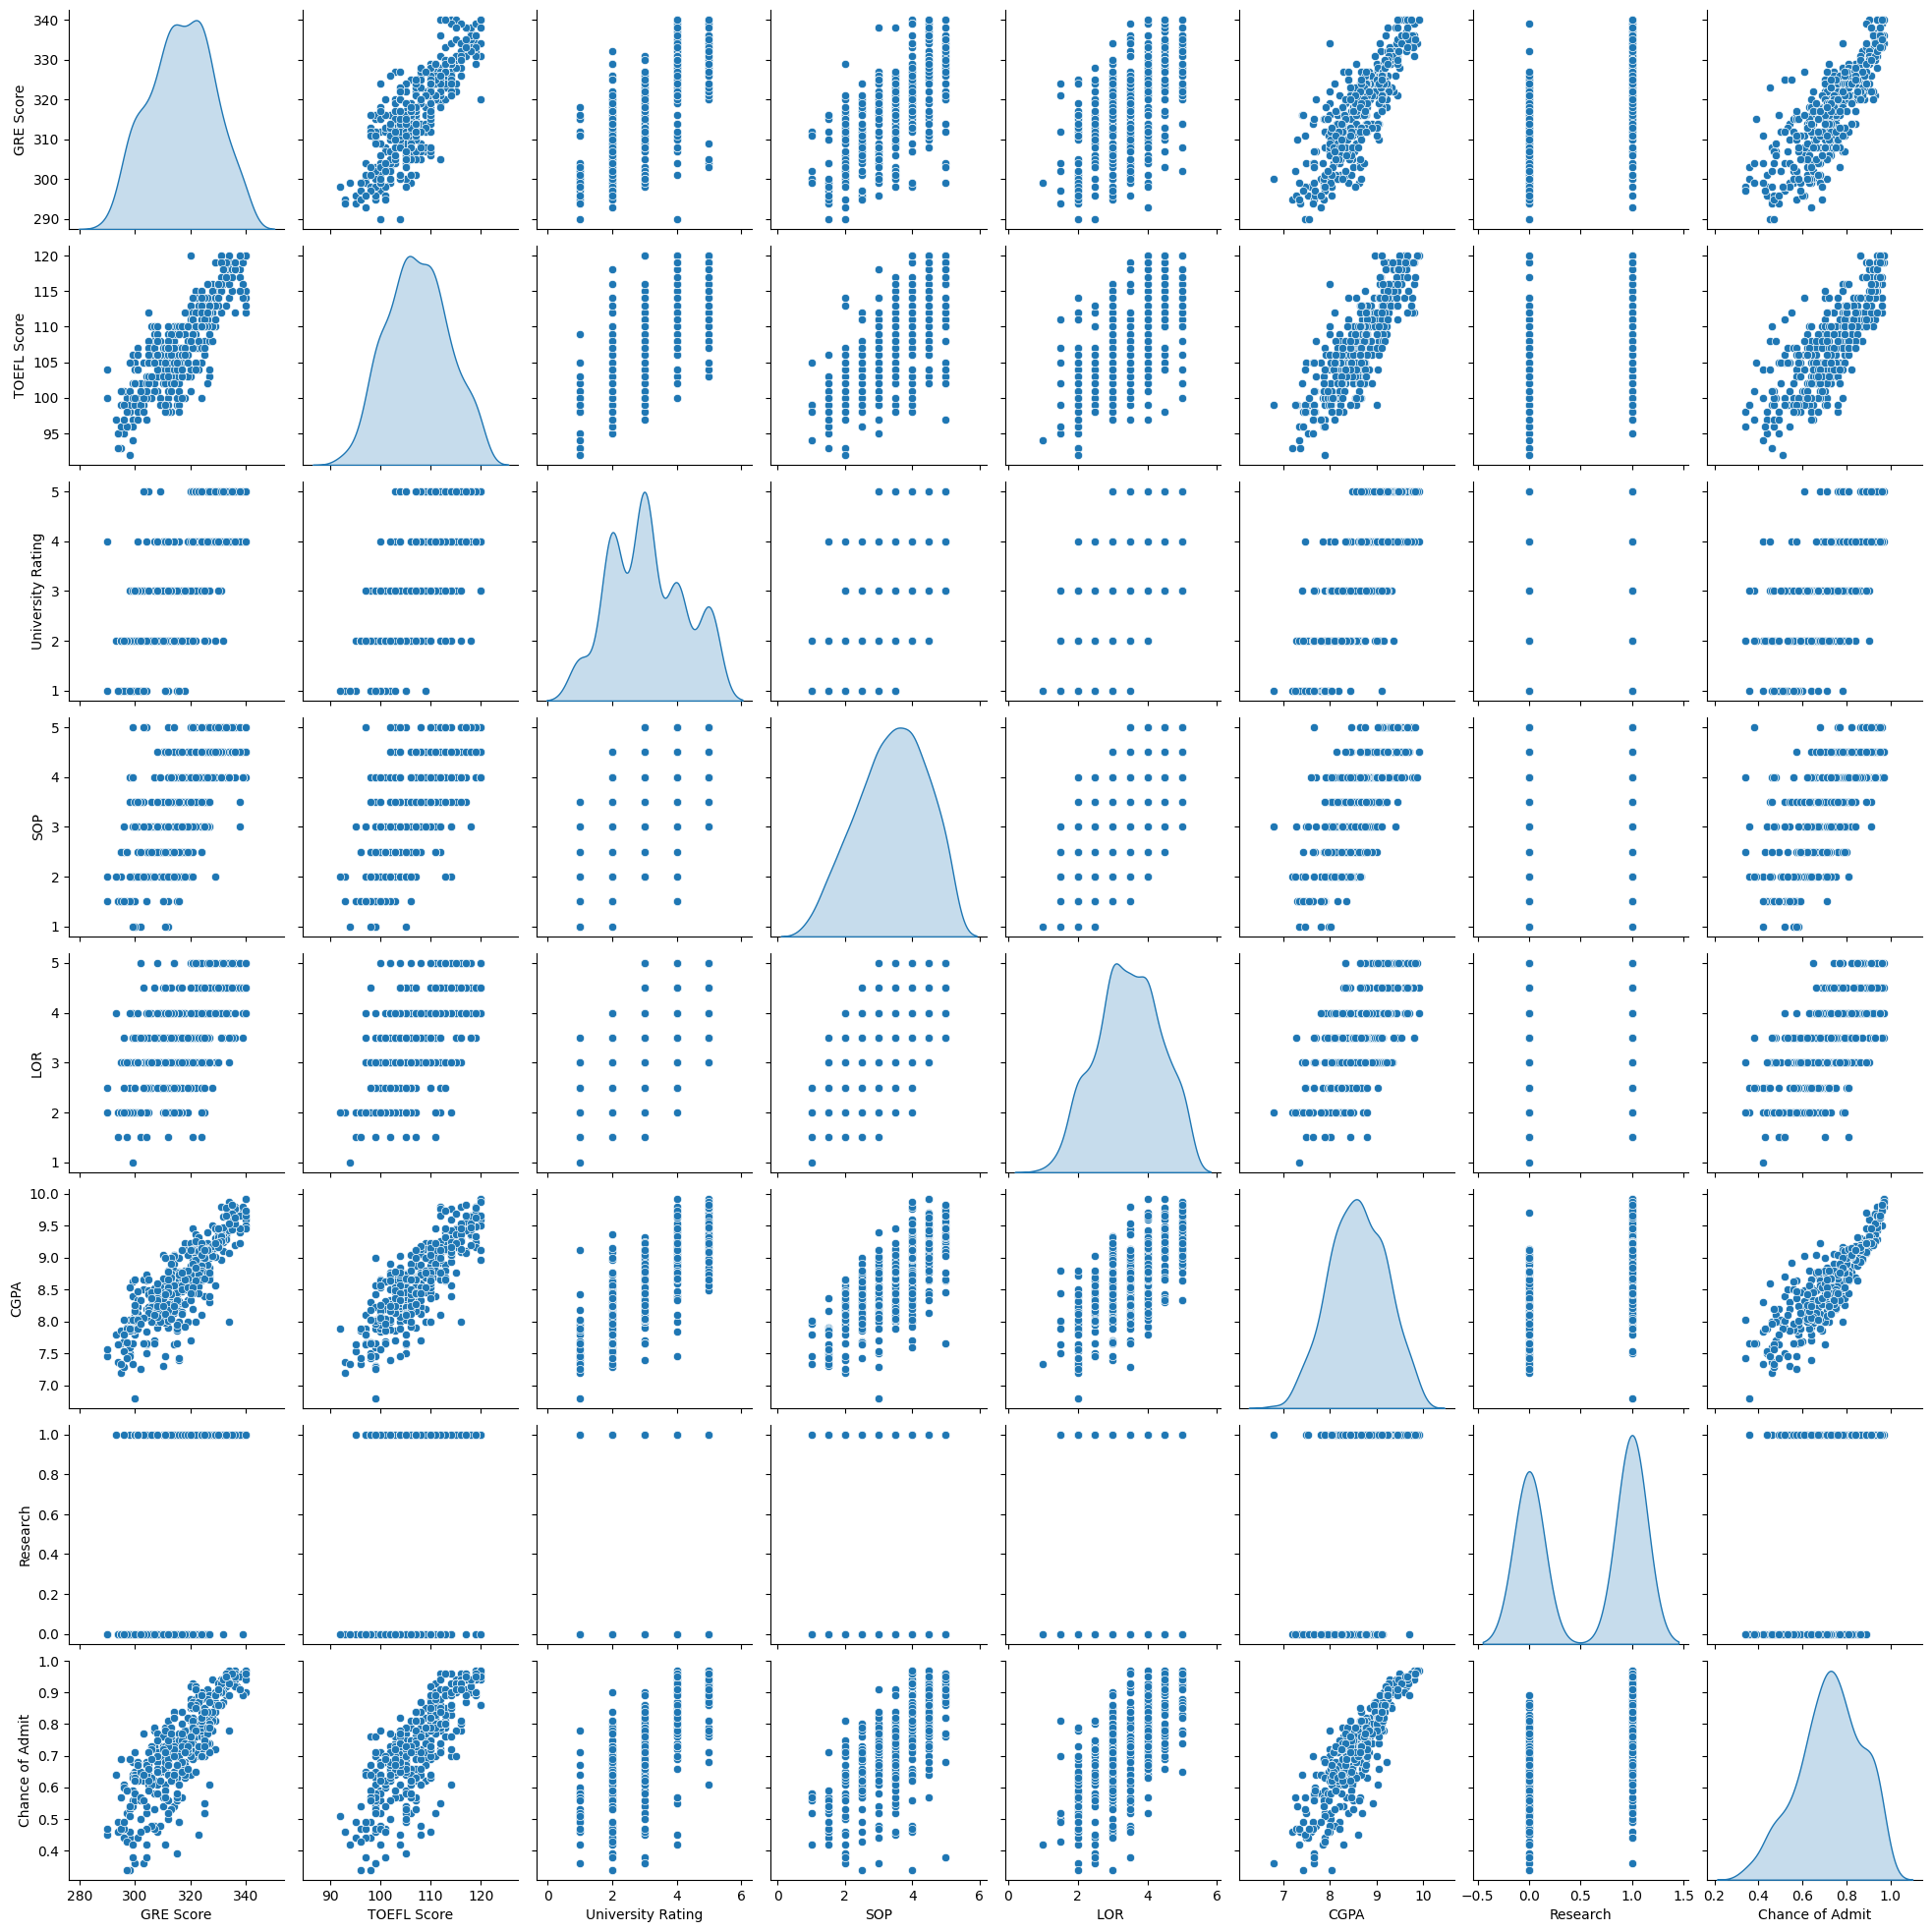

In [19]:
plt.figure(figsize=(12, 10))
sns.pairplot(dataset[['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA','Research', 'Chance of Admit']], diag_kind='kde')
plt.show()

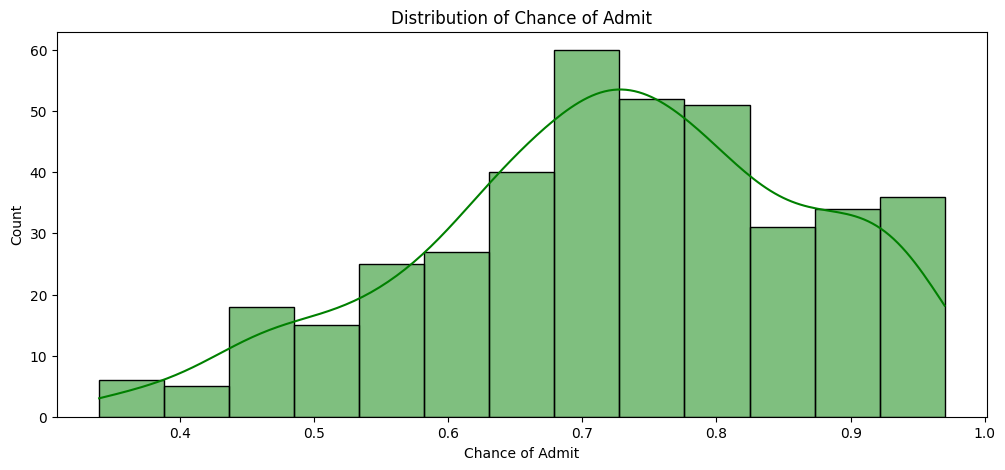

In [20]:
plt.figure(figsize=(12, 5))
sns.histplot(dataset['Chance of Admit'], kde=True, color='green')
plt.title("Distribution of Chance of Admit")
plt.show()

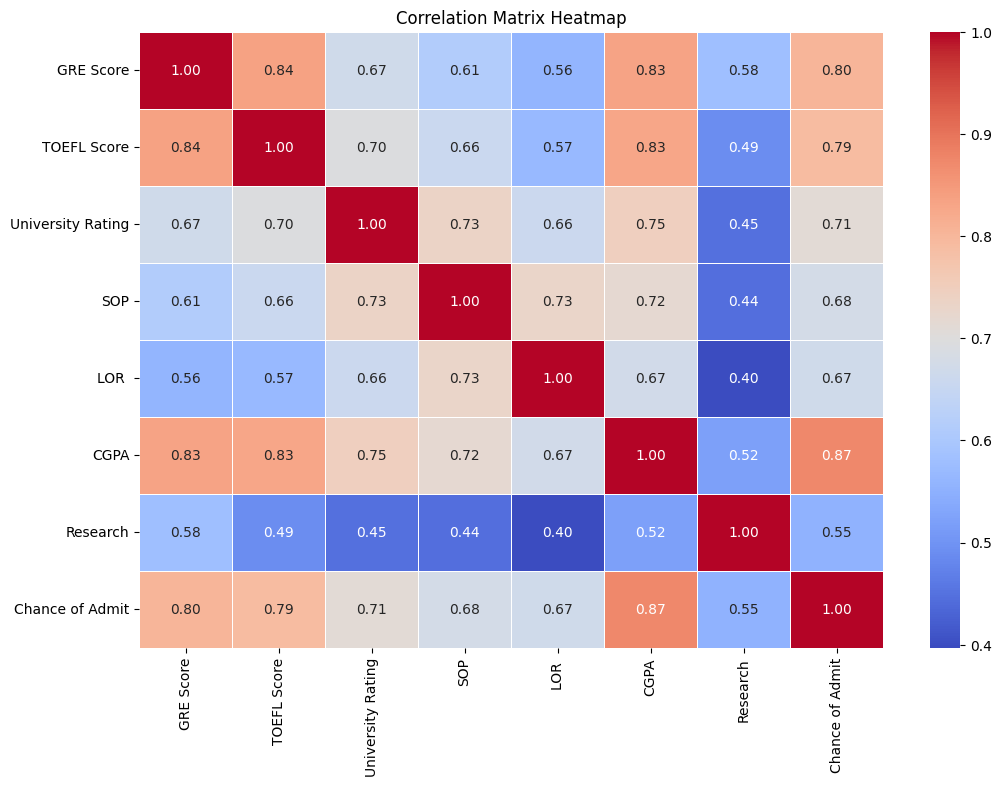

In [21]:
plt.figure(figsize=(12, 8))
corr = dataset[['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA','Research', 'Chance of Admit']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',linewidths=0.5,fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

In [24]:
X = dataset.drop(columns=['Chance of Admit'])
y = dataset['Chance of Admit']
#train-test split
x_train, x_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=0)
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size=0.50, random_state=0)
print("Shapes:")
print("X_train:", x_train.shape)
print("X_val:  ", x_val.shape)
print("X_test: ", x_test.shape)

print("\ny_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)


Shapes:
X_train: (320, 7)
X_val:   (40, 7)
X_test:  (40, 7)

y_train: (320,)
y_val:   (40,)
y_test:  (40,)


In [25]:
#scaler training data
scaler_X = StandardScaler()
x_train_scaled = scaler_X.fit_transform(x_train)
x_val_scaled = scaler_X.transform(x_val)
x_test_scaled = scaler_X.transform(x_test)

In [100]:
#regression models
knregressor=KNeighborsRegressor(n_neighbors=22, weights='distance',algorithm='auto', leaf_size=30, p=2, metric='euclidean', metric_params=None, n_jobs=-1)
knregressor.fit(x_train_scaled, y_train)
knn_y_pred=knregressor.predict(x_val_scaled)


kn_r2 = r2_score(y_val, knn_y_pred)
kn_mse = mean_squared_error(y_val, knn_y_pred)
kn_mae = mean_absolute_error(y_val, knn_y_pred)



dtr=DecisionTreeRegressor(criterion='friedman_mse',random_state=0,splitter='best',max_depth=8,min_samples_leaf=6,max_leaf_nodes=60,min_samples_split=6,max_features='sqrt')
dtr.fit(x_train_scaled, y_train)
dtr_y_pred=dtr.predict(x_val_scaled)

dtr_r2 = r2_score(y_val, dtr_y_pred)
dtr_mse = mean_squared_error(y_val, dtr_y_pred) 
dtr_mae = mean_absolute_error(y_val, dtr_y_pred)



random_forest_regressor=RandomForestRegressor(n_estimators=400,criterion='squared_error',max_depth=10,min_samples_split=6,min_samples_leaf=3,max_features='sqrt',max_leaf_nodes=100,n_jobs=-1, random_state=0)
random_forest_regressor.fit(x_train_scaled, y_train)
rfr_y_pred = random_forest_regressor.predict(x_val_scaled)

rfr_r2 = r2_score(y_val, rfr_y_pred)
rfr_mse = mean_squared_error(y_val, rfr_y_pred)
rfr_mae = mean_absolute_error(y_val, rfr_y_pred)



# Train SVR on the optimized data
svr_regressor = SVR(kernel='rbf', gamma='auto', epsilon=0.1, C=80)
svr_regressor.fit(x_train_scaled, y_train)

# Predict
svr_y_pred = svr_regressor.predict(x_val_scaled)


regression_results = {
    "Model": ["KNN Regressor", "Decision Tree", "Random Forest", "SVR"],
    "R2 Score": [kn_r2, dtr_r2, rfr_r2, r2_score(y_val, svr_y_pred)],
    "MSE": [kn_mse, dtr_mse, rfr_mse, mean_squared_error(y_val, svr_y_pred)],
    "MAE": [kn_mae, dtr_mae, rfr_mae, mean_absolute_error(y_val, svr_y_pred)]
}

df__regression_results = pd.DataFrame(regression_results)
print(df__regression_results)


           Model  R2 Score       MSE       MAE
0  KNN Regressor  0.635784  0.005300  0.054584
1  Decision Tree  0.457295  0.007897  0.068719
2  Random Forest  0.624927  0.005458  0.052041
3            SVR  0.437857  0.008180  0.072944


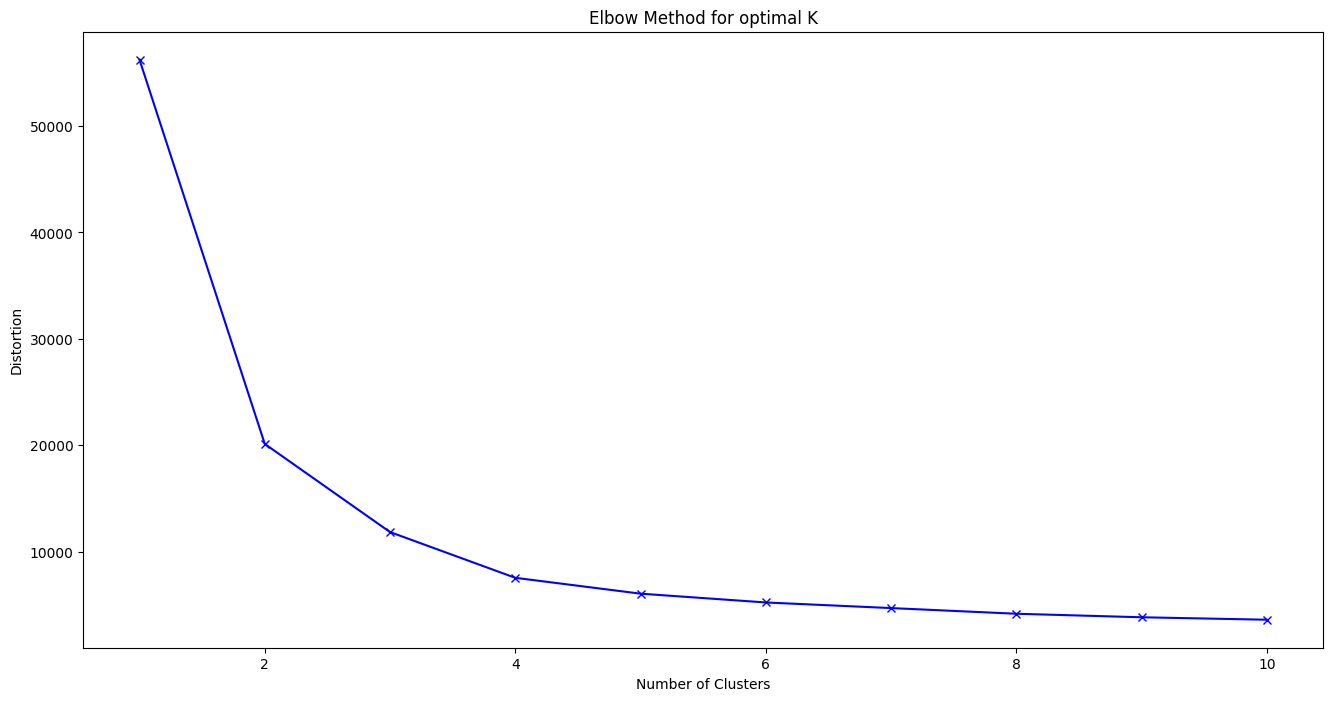

In [61]:
admissions_distortions = []
k_values=list(range(1,11))

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(x_train)
    admissions_distortions.append(kmeans.inertia_)
plt.figure(figsize=(16,8))
plt.plot(k_values,admissions_distortions,'bx-')
plt.xlabel("Number of Clusters")
plt.ylabel("Distortion")
plt.title("Elbow Method for optimal K")
plt.show()

In [62]:
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(x_train)
    score = silhouette_score(x_train, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.517
K=3, Silhouette Score=0.460
K=4, Silhouette Score=0.448
K=5, Silhouette Score=0.396
K=6, Silhouette Score=0.375


In [63]:
scaled_x_df=pd.DataFrame(x_train, columns=dataset.columns[:-1])
kmeans = KMeans(n_clusters=2, random_state=0)
scaled_x_df['KMEANS_Cluster'] = kmeans.fit_predict(scaled_x_df)
pca= PCA(n_components=2)
X_pca = pca.fit_transform(scaled_x_df)
scaled_x_df.groupby('KMEANS_Cluster').mean()


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
KMEANS_Cluster,,,,,,,
0,307.798817,103.189349,2.414201,2.878698,3.062130,8.203373,0.284024
1,326.933775,112.198675,3.894040,4.016556,3.940397,9.073974,0.867550


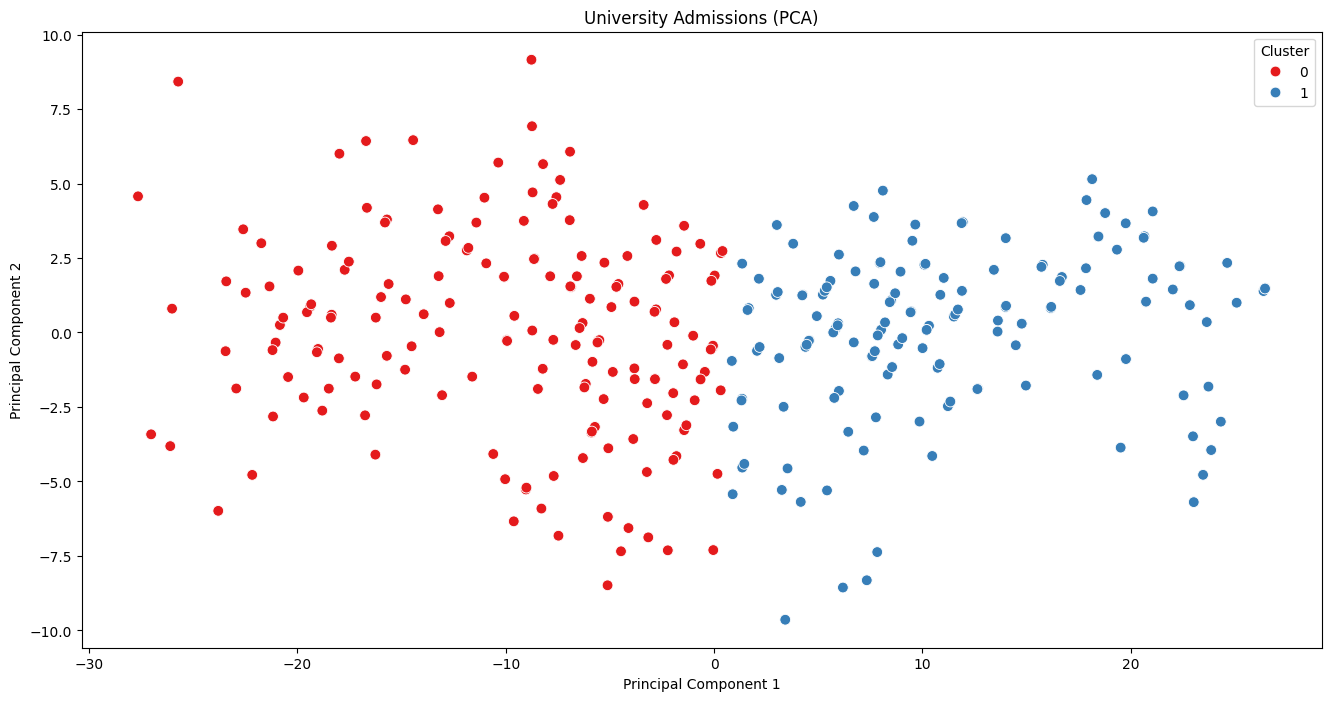

In [64]:
plt.figure(figsize=(16,8))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=scaled_x_df['KMEANS_Cluster'],
    palette='Set1',
    s=60
)

plt.title("University Admissions (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

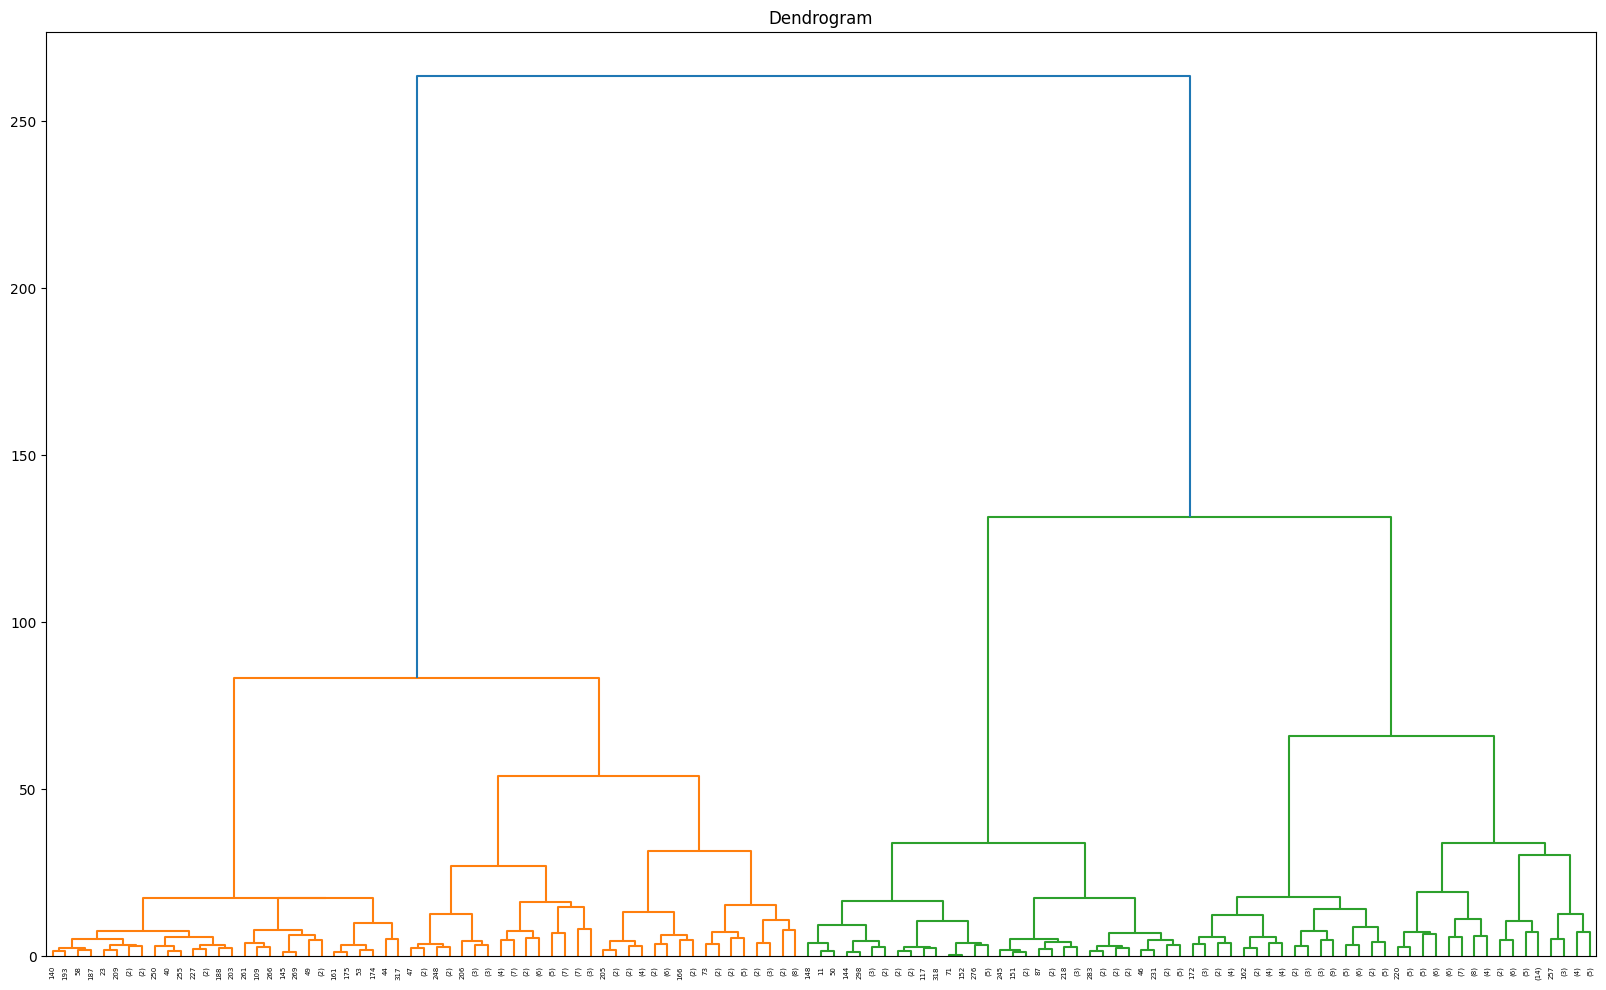

In [71]:
linkage_matrix = linkage(x_train, method='ward')
plt.figure(figsize=(20,12))
dendrogram(linkage_matrix,truncate_mode='level', p=6)
plt.title('Dendrogram')
plt.xlabel=('Features')
plt.ylabel=('Distance')
plt.show()

TypeError: 'str' object is not callable

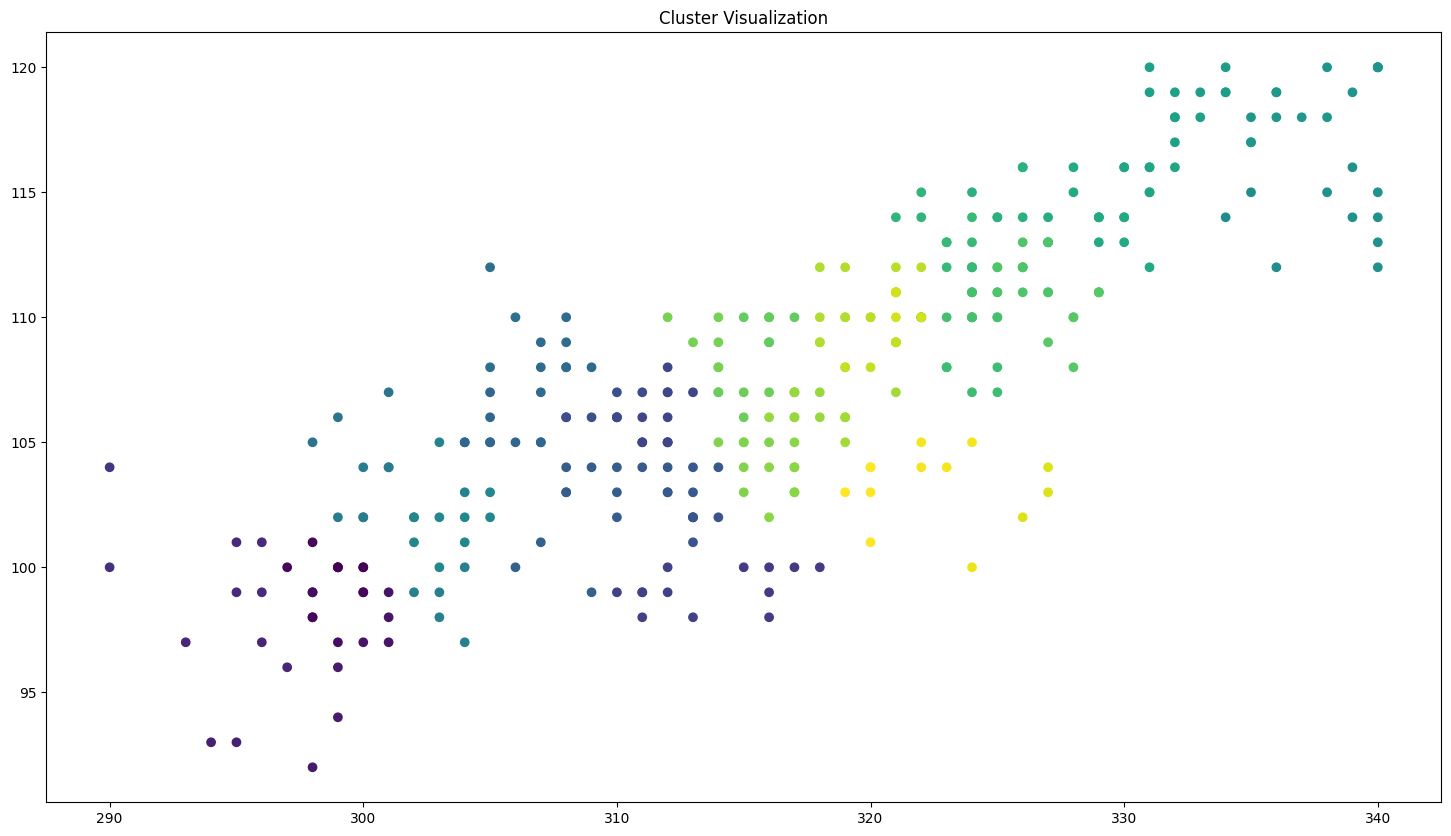

In [72]:
# Extract clusters based on a distance threshold
hierachical_clusters = fcluster(linkage_matrix, t=5, criterion='distance')
scaled_x_df['hie_clusters']=hierachical_clusters
dataset.head()
plt.figure(figsize=(18, 10))
plt.scatter(
    scaled_x_df.iloc[:, 0],
    scaled_x_df.iloc[:, 1],
    c=hierachical_clusters,
    cmap='viridis',
    marker='o'
)
plt.title("Cluster Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()



In [70]:
hie_score = silhouette_score(scaled_x_df, hierachical_clusters)
print(f"Silhouette Score: {hie_score:.2f}")

Silhouette Score: 0.36
